In [2]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load data set
df_sequence_spoilage = pd.read_csv("data/raw/sequence_spoilage.csv", sep="|")
df_sequence_spoilage.fillna(0, inplace=True)
df_sequence_spoilage.drop_duplicates(inplace=True)
df_Assignment_History = pd.read_csv("data/raw/Assignment_History.csv")
df_Assignment_History.fillna(0, inplace=True)
df_Assignment_History.drop_duplicates(inplace=True)
df_Flight_Data_With_Weather = pd.read_csv("Flight_Data_With_Weather_FINAL.csv")
df_Flight_Data_With_Weather.fillna(0, inplace=True)
df_Flight_Data_With_Weather.drop_duplicates(inplace=True)


/var/folders/05/nr6c3d_n40sbhlx02vwk20hc0000gn/T/ipykernel_10943/3215490629.py:5: DtypeWarning: Columns (32,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_Assignment_History = pd.read_csv("data/raw/Assignment_History.csv")


In [36]:
# Create a joined dataset for the variables above
joined_df = df_Flight_Data_With_Weather.loc[:, ['FLEET', 'BASE','SEQ_TTL_LEGS','TOTAL_SPOILED_HRS','TOTAL_BLOCKED_HRS','LAYOVER','SPOILAGE','VIS_MILES']]
mapping = {
    "NOT SPOILED": 0,
    "PARTIALLY SPOILED": 0.5,
    "FULLY SPOILED": 1
}


joined_df["SPOILAGE_RATE"] = df_Flight_Data_With_Weather["SPOILAGE"].map(mapping)


In [37]:
# Step 1: One-hot encode categorical variables
df_model = pd.get_dummies(joined_df, columns=["BASE", "FLEET"], drop_first=False)

# Step 2: Select features
features = [
    "SEQ_TTL_LEGS",
    "TOTAL_BLOCKED_HRS",
    "LAYOVER",
    "VIS_MILES",
    "SPOILAGE_RATE"
]

features += [col for col in df_model.columns if col.startswith("BASE_") or col.startswith("FLEET_")]

df_corr = df_model[features]

# Step 3: Compute correlation
corr = df_corr.corr()
target_corr = corr["SPOILAGE_RATE"].drop("SPOILAGE_RATE").sort_values()
target_corr.sort_values(ascending=False)

SEQ_TTL_LEGS         0.163007
TOTAL_BLOCKED_HRS    0.087930
FLEET_320            0.052971
BASE_LGA             0.037917
FLEET_737            0.024222
BASE_BOS             0.019833
BASE_LAX             0.015114
BASE_PHL             0.012100
BASE_CLT             0.010445
LAYOVER              0.005168
BASE_PHX             0.003908
BASE_ORD            -0.000606
BASE_MIA            -0.005681
BASE_DCA            -0.009604
VIS_MILES           -0.027124
BASE_DFW            -0.031525
FLEET_787           -0.056629
FLEET_777           -0.062483
Name: SPOILAGE_RATE, dtype: float64

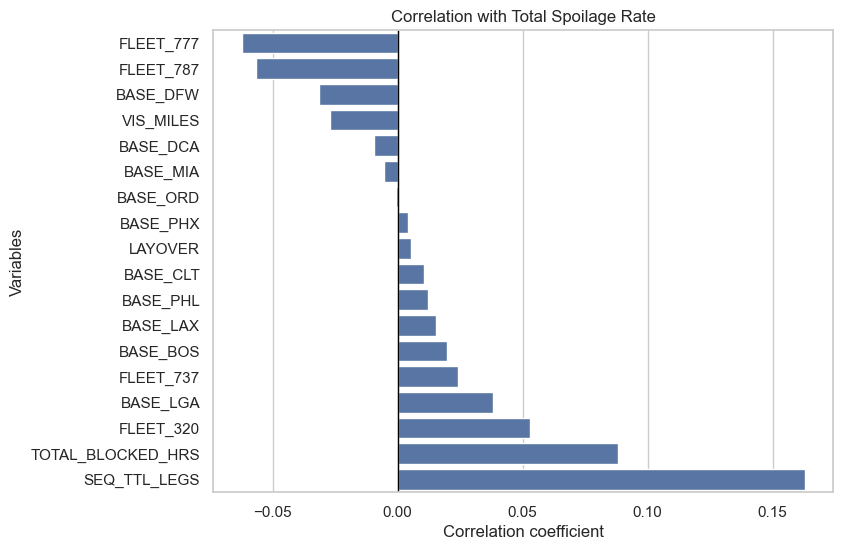

In [39]:
plt.figure(figsize=(8, 6))

# Added color="blue" here
sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)

plt.title("Correlation with Total Spoilage Rate")
plt.xlabel("Correlation coefficient")
plt.ylabel("Variables")

# Still good practice to add a vertical line at 0 for context
plt.axvline(0, color='black', lw=1)

plt.show()